## Statsforecast for GPU Utilization

### Without exogeneous variables

In [1]:
from statsforecast import StatsForecast

In [2]:
import pandas as pd

In [3]:
Y_df = pd.read_csv('data/gpu_slurm_metrics_10s_cleaned.csv') # load the data
Y_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259185 entries, 0 to 1259184
Data columns (total 10 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   timestamp               1259185 non-null  object 
 1   gpu_index               1259185 non-null  int64  
 2   utilization_gpu_pct     1259185 non-null  float64
 3   utilization_memory_pct  1259185 non-null  float64
 4   temperature_gpu         1259185 non-null  float64
 5   temperature_memory      1259185 non-null  float64
 6   power_draw_W            1259185 non-null  float64
 7   id_job                  1259185 non-null  int64  
 8   time_start              1259185 non-null  float64
 9   time_end                1259185 non-null  float64
dtypes: float64(7), int64(2), object(1)
memory usage: 96.1+ MB


In [4]:
Y_df['unique_id'] = Y_df['id_job'].astype(str) + '_gpu' + Y_df['gpu_index'].astype(str)

In [5]:
Y_df['timestamp'] = pd.to_datetime(Y_df['timestamp'])
Y_df = Y_df.sort_values(by=['unique_id', 'timestamp'])

In [6]:
# Create a numerical index 'ds' that starts from 0 for each series.
# This is crucial for Nixtla models and handles variable start times and durations.
Y_df['ds'] = Y_df.groupby('unique_id').cumcount()

In [7]:
Y_df['y'] = Y_df['power_draw_W']

In [8]:
Y_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1259185 entries, 264388 to 463474
Data columns (total 13 columns):
 #   Column                  Non-Null Count    Dtype         
---  ------                  --------------    -----         
 0   timestamp               1259185 non-null  datetime64[ns]
 1   gpu_index               1259185 non-null  int64         
 2   utilization_gpu_pct     1259185 non-null  float64       
 3   utilization_memory_pct  1259185 non-null  float64       
 4   temperature_gpu         1259185 non-null  float64       
 5   temperature_memory      1259185 non-null  float64       
 6   power_draw_W            1259185 non-null  float64       
 7   id_job                  1259185 non-null  int64         
 8   time_start              1259185 non-null  float64       
 9   time_end                1259185 non-null  float64       
 10  unique_id               1259185 non-null  object        
 11  ds                      1259185 non-null  int64         
 12  y              

In [9]:
# This is the standard format for Nixtla.
prepared_df = Y_df[['unique_id', 'ds', 'y']]

print("Data prepared successfully. Head of the DataFrame:")
print(prepared_df.head())
print(f"\nNumber of unique time series (job-gpu combinations): {prepared_df['unique_id'].nunique()}")

Data prepared successfully. Head of the DataFrame:
                  unique_id  ds          y
264388  10217518336509_gpu0   0  54.939016
471025  10217518336509_gpu0   1  46.433710
264389  10217518336509_gpu0   2  53.556915
471026  10217518336509_gpu0   3  46.569681
264390  10217518336509_gpu0   4  52.611935

Number of unique time series (job-gpu combinations): 414


In [10]:
Y_df.head()

,timestamp,gpu_index,utilization_gpu_pct,utilization_memory_pct,temperature_gpu,temperature_memory,power_draw_W,id_job,time_start,time_end,unique_id,ds,y
264388,2021-06-07 20:24:30,0,6.360656,0.360656,65.180328,66.393443,54.939016,10217518336509,1.623112e+09,1.623137e+09,10217518336509_gpu0,0,54.939016
471025,2021-06-07 20:24:30,0,0.435484,0.000000,40.000000,38.080645,46.433710,10217518336509,1.623112e+09,1.623137e+09,10217518336509_gpu0,1,46.433710
264389,2021-06-07 20:24:40,0,0.031915,0.010638,63.638298,64.861702,53.556915,10217518336509,1.623112e+09,1.623137e+09,10217518336509_gpu0,2,53.556915
471026,2021-06-07 20:24:40,0,0.063830,0.021277,40.000000,38.042553,46.569681,10217518336509,1.623112e+09,1.623137e+09,10217518336509_gpu0,3,46.569681
264390,2021-06-07 20:24:50,0,1.150538,0.032258,62.311828,63.387097,52.611935,10217518336509,1.623112e+09,1.623137e+09,10217518336509_gpu0,4,52.611935


In [11]:
# h = (5 minutes * 60 seconds/minute) / 10 seconds/sample = 30 steps
h = 30

# Split data into training and testing sets
# The test set is the last 'h' steps of EACH time series.
train_df = prepared_df.groupby('unique_id').head(-h)
test_df = prepared_df.groupby('unique_id').tail(h)

print(f"Training set size: {len(train_df)}")
print(f"Test set size: {len(test_df)}")

Training set size: 1246765
Test set size: 12420


In [12]:
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA,AutoETS, AutoTheta

# seasonal_length=6 for 1 minute
sf_models = [
    AutoARIMA(season_length=6),
    AutoETS(season_length=6),
    AutoTheta(season_length=6)
]

sf = StatsForecast(
    models=sf_models,
    freq=1, # Since we created an integer 'ds' index
    n_jobs=-1 # Use all available cores
)

# 3. Get predictions
# The forecast method takes the training data and predicts 'h' steps for each series.
# Note: StatsForecast is smart and uses the last available data from train_df to forecast.
forecast_sf_df = sf.forecast(df=train_df, h=h)

# Merge with true values for evaluation
forecast_sf_df = forecast_sf_df.merge(test_df, on=['unique_id', 'ds'], how='left')

print("StatsForecast predictions:")
print(forecast_sf_df.head())

/project/home/p200631/conda_base_path/miniconda3/envs/spark-env/lib/python3.11/site-packages/statsforecast/arima.py:1867: UserWarning: Stepwise search was stopped early due to reaching the model number limit: nmodels=94
  warnings.warn(


StatsForecast predictions:
             unique_id    ds   AutoARIMA     AutoETS   AutoTheta           y
0  10217518336509_gpu0  5048  170.171867  170.004316  170.443795  167.222043
1  10217518336509_gpu0  5049  183.362046  183.055458  183.554104  182.227021
2  10217518336509_gpu0  5050  170.349896  169.982996  170.435505  170.289140
3  10217518336509_gpu0  5051  183.870342  182.954417  183.373296  183.194681
4  10217518336509_gpu0  5052  170.258198  170.096829  170.513195  171.555484


In [13]:
forecast_sf_df

,unique_id,ds,AutoARIMA,AutoETS,AutoTheta,y
0,10217518336509_gpu0,5048,170.171867,170.004316,170.443795,167.222043
1,10217518336509_gpu0,5049,183.362046,183.055458,183.554104,182.227021
2,10217518336509_gpu0,5050,170.349896,169.982996,170.435505,170.289140
3,10217518336509_gpu0,5051,183.870342,182.954417,183.373296,183.194681
4,10217518336509_gpu0,5052,170.258198,170.096829,170.513195,171.555484
...,...,...,...,...,...,...
12415,9976590120891_gpu1,14525,39.936562,39.900043,39.873895,39.754217
12416,9976590120891_gpu1,14526,39.823397,39.900068,39.875950,39.550602
12417,9976590120891_gpu1,14527,39.814423,39.900089,39.870882,39.772892
12418,9976590120891_gpu1,14528,39.940118,39.900105,39.872497,39.958072


In [17]:
fcst_no_e = forecast_sf_df[["unique_id", "ds", "AutoARIMA", "AutoETS", "AutoTheta"]]

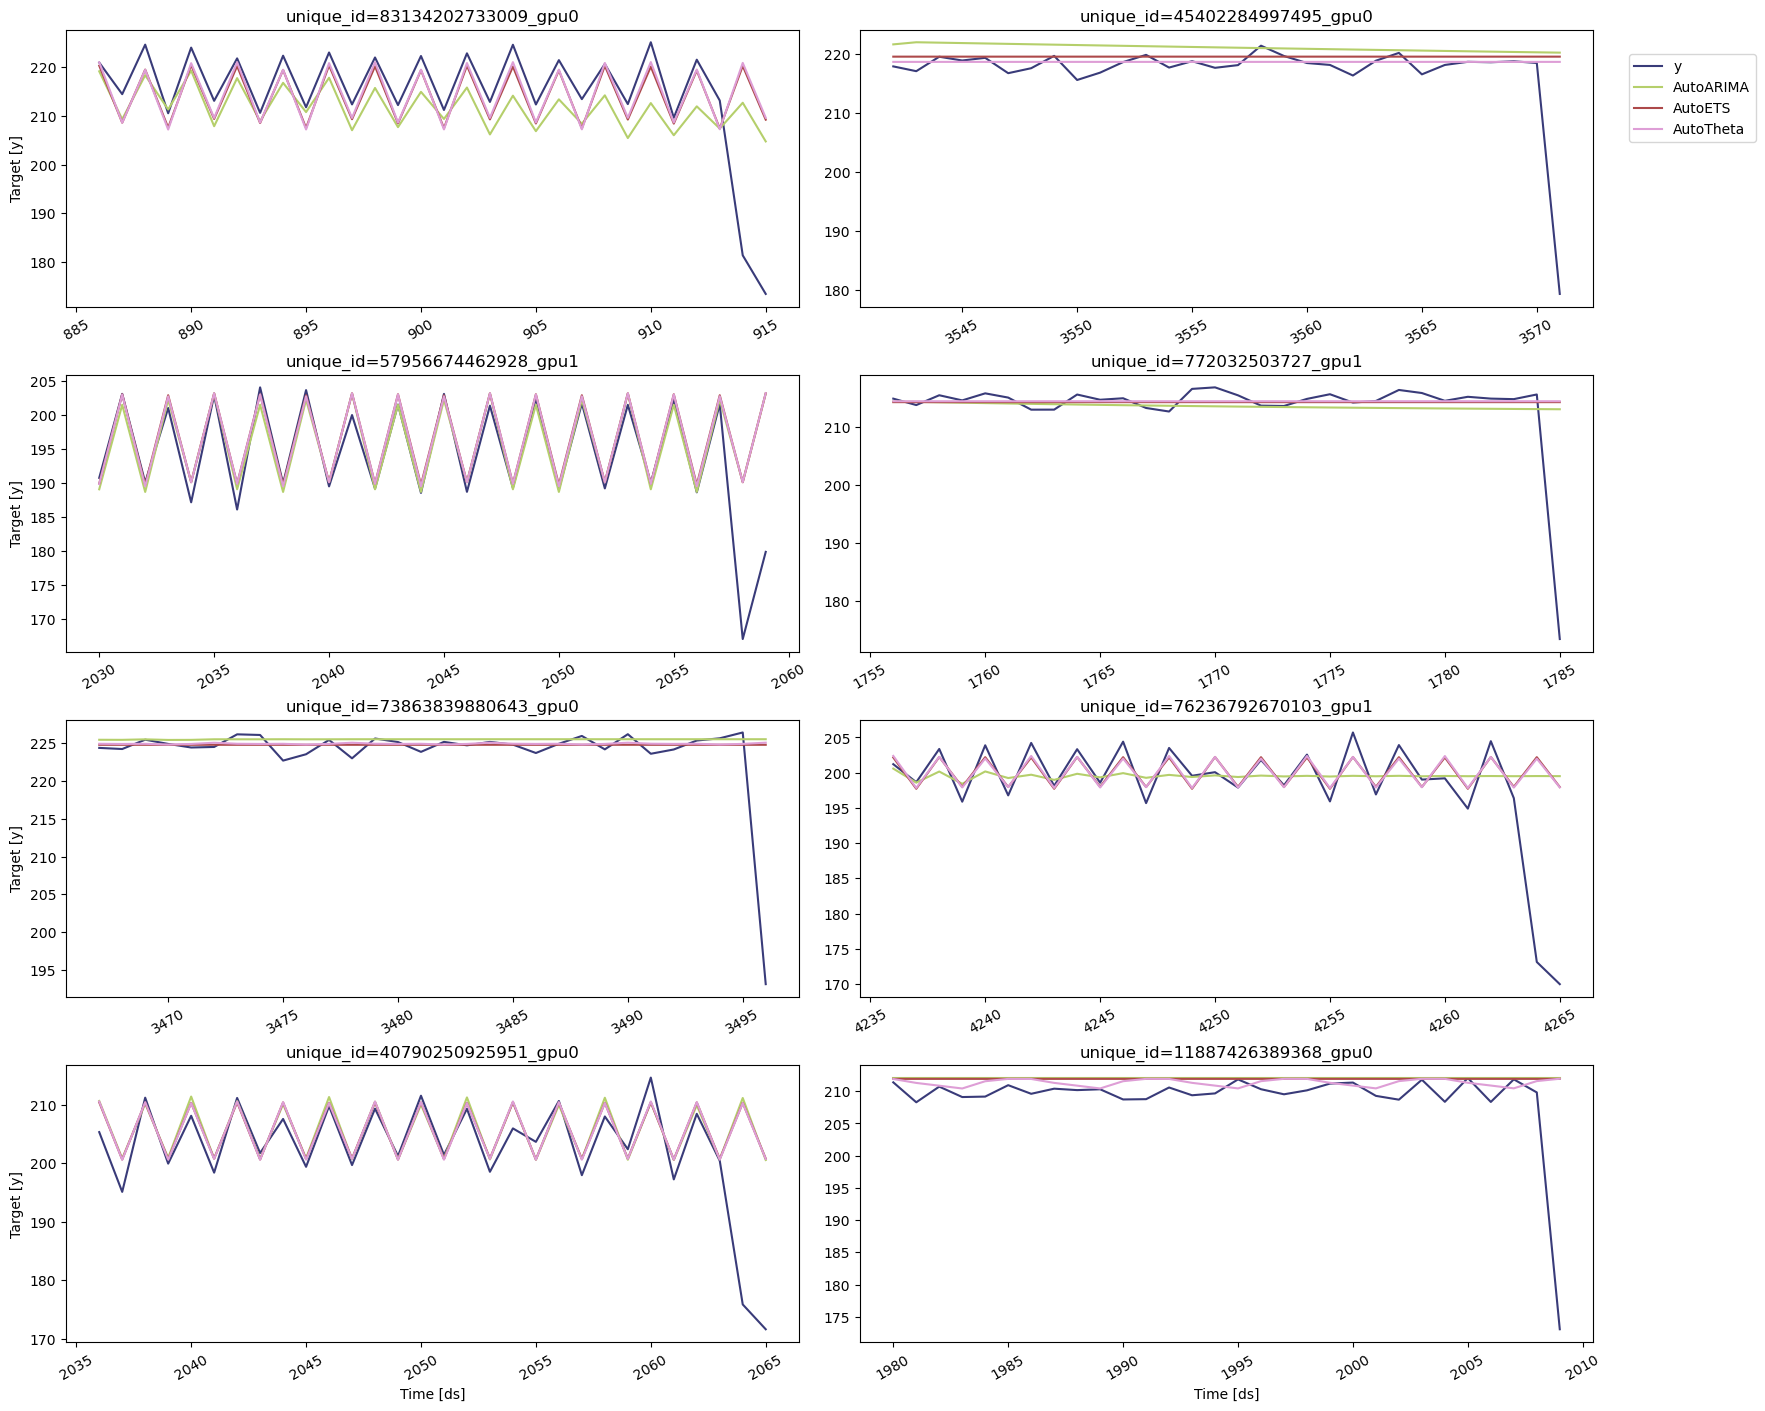

In [18]:
StatsForecast.plot(test_df, fcst_no_e, max_insample_length=30*2)

In [16]:
import polars as pl
import pandas as pd
import numpy as np
from utilsforecast.losses import mae, rmse, mse, mape, smape

def evaluate_forecast(df, y_col="y", id_col="unique_id", ds_col="ds"):
    # Detect all forecast model columns (exclude id, ds, y)
    model_cols = [c for c in df.columns if c not in [id_col, ds_col, y_col, "Unnamed: 0"]]
    
    # Convert pandas → polars
    pl_df = pl.from_pandas(df[[id_col, y_col] + model_cols])
    
    # -----------------
    # Per-series metrics
    # -----------------
    results = {
        "MAE": mae(pl_df, models=model_cols, id_col=id_col, target_col=y_col),
        "RMSE": rmse(pl_df, models=model_cols, id_col=id_col, target_col=y_col),
        "MSE": mse(pl_df, models=model_cols, id_col=id_col, target_col=y_col),
        "MAPE": mape(pl_df, models=model_cols, id_col=id_col, target_col=y_col),
        "sMAPE": smape(pl_df, models=model_cols, id_col=id_col, target_col=y_col),
    }
    
    metrics_df = None
    for name, metric in results.items():
        metric = metric.rename({c: f"{c}_{name}" for c in metric.columns if c != id_col})
        metrics_df = metric if metrics_df is None else metrics_df.join(metric, on=id_col, how="inner")
    per_series_metrics = metrics_df.to_pandas()
    
    # -----------------
    # Global metrics
    # -----------------
    global_results = []
    y_true = df[y_col].values
    
    for model in model_cols:
        y_pred = df[model].values
        global_results.append({
            "Model": model,
            "MAE": np.mean(np.abs(y_true - y_pred)),
            "RMSE": np.sqrt(np.mean((y_true - y_pred) ** 2)),
            "MSE": np.mean((y_true - y_pred) ** 2),
            "MAPE": np.mean(np.abs((y_true - y_pred) / y_true)) * 100,
            "sMAPE": np.mean(200 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred))),
            "wMAPE": np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100,
        })
    
    global_metrics = pd.DataFrame(global_results)
    
    return per_series_metrics, global_metrics

# Example usage
per_series_metrics, global_metrics = evaluate_forecast(forecast_sf_df)

print("Per-series metrics:\n", per_series_metrics.head())
print("\nGlobal metrics:\n", global_metrics)


Per-series metrics:
              unique_id  AutoARIMA_MAE  AutoETS_MAE  AutoTheta_MAE  \
0  10217518336509_gpu0       4.570662     4.520187       4.602777   
1  10217518336509_gpu1       3.909456     3.915945       3.893243   
2  10297115157410_gpu1       2.867669     2.870537       2.902811   
3  10612452483078_gpu0       3.359631     3.462876       3.458272   
4  10612452483078_gpu1       3.525904     2.906413       2.913742   

   AutoARIMA_RMSE  AutoETS_RMSE  AutoTheta_RMSE  AutoARIMA_MSE  AutoETS_MSE  \
0       12.294083     12.254547       12.370255     151.144466   150.173923   
1       11.024425     11.169952       11.121190     121.537939   124.767827   
2       10.055886     10.062681       10.052546     101.120838   101.257548   
3       11.238417     11.290783       11.289955     126.302010   127.481791   
4       11.064375     11.247944       11.245737     122.420395   126.516237   

   AutoTheta_MSE  AutoARIMA_MAPE  AutoETS_MAPE  AutoTheta_MAPE  \
0     153.023203       

### With exogeneous regressors

In [19]:
Y_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1259185 entries, 264388 to 463474
Data columns (total 13 columns):
 #   Column                  Non-Null Count    Dtype         
---  ------                  --------------    -----         
 0   timestamp               1259185 non-null  datetime64[ns]
 1   gpu_index               1259185 non-null  int64         
 2   utilization_gpu_pct     1259185 non-null  float64       
 3   utilization_memory_pct  1259185 non-null  float64       
 4   temperature_gpu         1259185 non-null  float64       
 5   temperature_memory      1259185 non-null  float64       
 6   power_draw_W            1259185 non-null  float64       
 7   id_job                  1259185 non-null  int64         
 8   time_start              1259185 non-null  float64       
 9   time_end                1259185 non-null  float64       
 10  unique_id               1259185 non-null  object        
 11  ds                      1259185 non-null  int64         
 12  y              

In [20]:
Y_ts = Y_df[['unique_id', 'ds', 'y']]

In [21]:
exog_vars = ['utilization_memory_pct', 'temperature_gpu', 'temperature_memory', 'utilization_gpu_pct']
X_ts = Y_df[['unique_id', 'ds'] + exog_vars]

In [22]:
X_ts['unique_id'] = X_ts.unique_id.astype(str)
X_ts.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1259185 entries, 264388 to 463474
Data columns (total 6 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   unique_id               1259185 non-null  object 
 1   ds                      1259185 non-null  int64  
 2   utilization_memory_pct  1259185 non-null  float64
 3   temperature_gpu         1259185 non-null  float64
 4   temperature_memory      1259185 non-null  float64
 5   utilization_gpu_pct     1259185 non-null  float64
dtypes: float64(4), int64(1), object(1)
memory usage: 67.2+ MB


/tmp/ipykernel_7841/1014213204.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_ts['unique_id'] = X_ts.unique_id.astype(str)


In [23]:
# h = (5 minutes * 60 seconds/minute) / 10 seconds/sample = 30 steps
h = 30

# Split data into training and testing sets
# The test set is the last 'h' steps of EACH time series.
Y_train = Y_ts.groupby('unique_id').head(-h)
Y_test = Y_ts.groupby('unique_id').tail(h)

X_train = X_ts.groupby('unique_id').head(-h)
X_test = X_ts.groupby('unique_id').tail(h)

print(f"Training set size: {len(Y_train)}")
print(f"Test set size: {len(Y_test)}")

Training set size: 1246765
Test set size: 12420


In [24]:
train = Y_train.merge(X_ts, how = 'left', on = ['unique_id', 'ds']) 
train.head()

,unique_id,ds,y,utilization_memory_pct,temperature_gpu,temperature_memory,utilization_gpu_pct
0,10217518336509_gpu0,0,54.939016,0.360656,65.180328,66.393443,6.360656
1,10217518336509_gpu0,1,46.433710,0.000000,40.000000,38.080645,0.435484
2,10217518336509_gpu0,2,53.556915,0.010638,63.638298,64.861702,0.031915
3,10217518336509_gpu0,3,46.569681,0.021277,40.000000,38.042553,0.063830
4,10217518336509_gpu0,4,52.611935,0.032258,62.311828,63.387097,1.150538


In [25]:
X_test.head()

,unique_id,ds,utilization_memory_pct,temperature_gpu,temperature_memory,utilization_gpu_pct
266912,10217518336509_gpu0,5048,32.516129,67.956989,70.602151,94.655914
473549,10217518336509_gpu0,5049,32.851064,68.159574,68.489362,94.978723
266913,10217518336509_gpu0,5050,32.602151,67.784946,70.408602,94.935484
473550,10217518336509_gpu0,5051,33.329787,68.297872,68.776596,94.914894
266914,10217518336509_gpu0,5052,32.526882,68.010753,70.827957,94.279570


In [26]:
from statsforecast.models import AutoARIMA,AutoETS, AutoTheta

# seasonal_length=6 for 1 minute
sf_models = [
    AutoARIMA(season_length=6),
    AutoETS(season_length=6),
    AutoTheta(season_length=6)
]

sf = StatsForecast(
    models=sf_models,
    freq=1, # Since we created an integer 'ds' index
    n_jobs=-1 # Use all available cores
)

In [27]:
horizon = 30

fcst = sf.forecast(df=train, h=horizon, X_df=X_test)
fcst.head()

,unique_id,ds,AutoARIMA,AutoETS,AutoTheta
0,10217518336509_gpu0,5048,169.517371,170.004316,170.443795
1,10217518336509_gpu0,5049,183.474545,183.055458,183.554104
2,10217518336509_gpu0,5050,169.814450,169.982996,170.435505
3,10217518336509_gpu0,5051,182.845667,182.954417,183.373296
4,10217518336509_gpu0,5052,168.152916,170.096829,170.513195


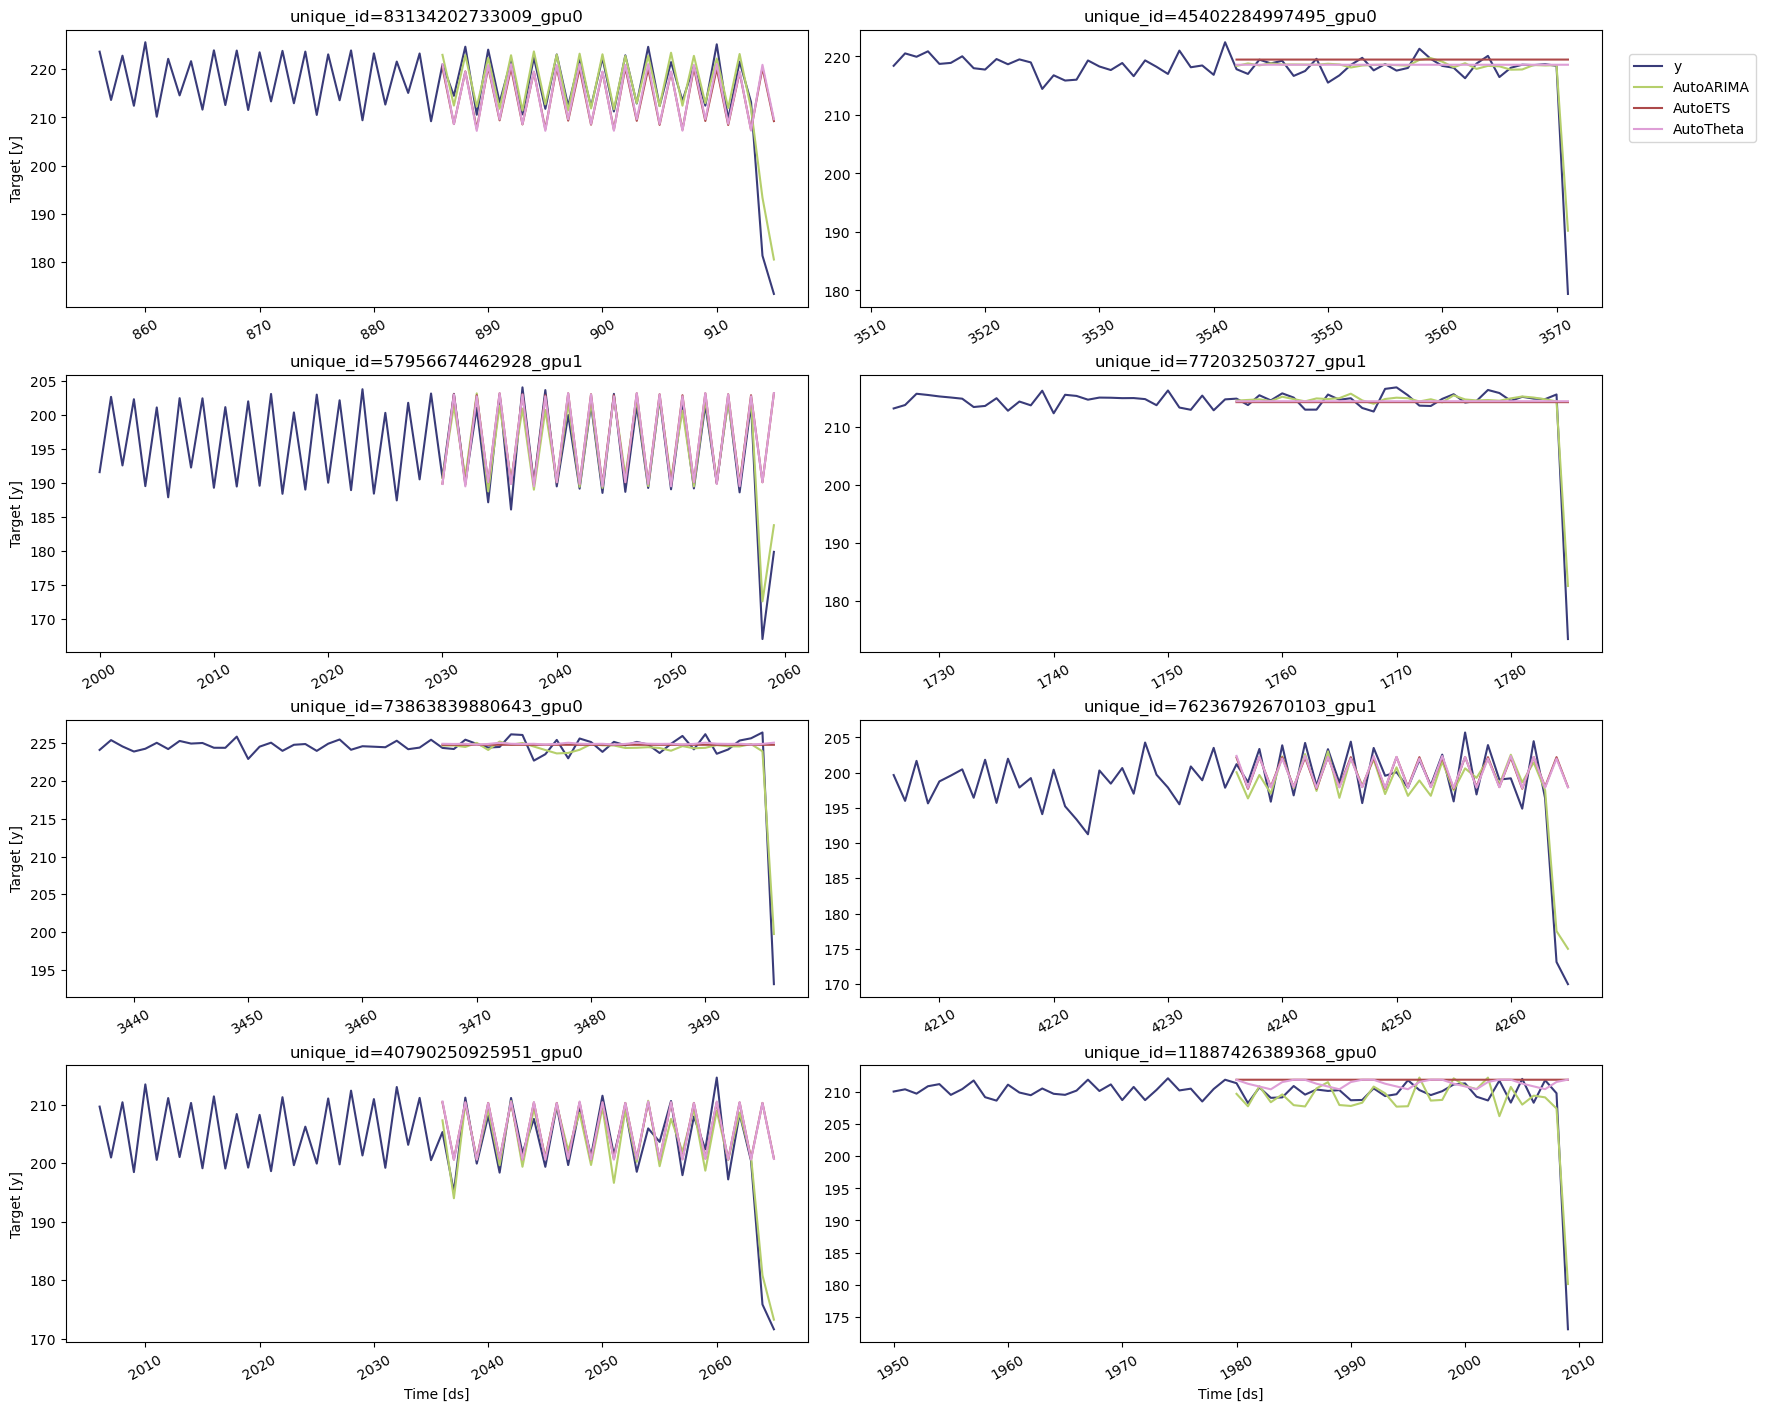

In [28]:
StatsForecast.plot(Y_ts, fcst, max_insample_length=30*2)

In [29]:
res = Y_test.merge(fcst, how='left', on=['unique_id', 'ds'])
res.head()

,unique_id,ds,y,AutoARIMA,AutoETS,AutoTheta
0,10217518336509_gpu0,5048,167.222043,169.517371,170.004316,170.443795
1,10217518336509_gpu0,5049,182.227021,183.474545,183.055458,183.554104
2,10217518336509_gpu0,5050,170.289140,169.814450,169.982996,170.435505
3,10217518336509_gpu0,5051,183.194681,182.845667,182.954417,183.373296
4,10217518336509_gpu0,5052,171.555484,168.152916,170.096829,170.513195


In [30]:
per_series_metrics, global_metrics = evaluate_forecast(res)

print("Per-series metrics:")
print(per_series_metrics.head())

print("\nGlobal metrics:")
print(global_metrics)

Per-series metrics:
             unique_id  AutoARIMA_MAE  AutoETS_MAE  AutoTheta_MAE  \
0  10217518336509_gpu0       2.743257     4.520187       4.602777   
1  10217518336509_gpu1       2.033807     3.915945       3.893243   
2  10297115157410_gpu1       1.733020     2.870537       2.902811   
3  10612452483078_gpu0       1.481730     3.462876       3.458272   
4  10612452483078_gpu1       1.143526     2.906413       2.913742   

   AutoARIMA_RMSE  AutoETS_RMSE  AutoTheta_RMSE  AutoARIMA_MSE  AutoETS_MSE  \
0        4.890987     12.254547       12.370255      23.921750   150.173923   
1        3.391498     11.169952       11.121190      11.502257   124.767827   
2        4.000398     10.062681       10.052546      16.003185   101.257548   
3        2.102194     11.290783       11.289955       4.419221   127.481791   
4        1.621208     11.247944       11.245737       2.628316   126.516237   

   AutoTheta_MSE  AutoARIMA_MAPE  AutoETS_MAPE  AutoTheta_MAPE  \
0     153.023203        

In [ ]:
2.242400   
7.292726   
53.183849  
2.060036  
1.625093  
1.180839